<a href="https://colab.research.google.com/github/raniyaarani13-web/north-star-analytics/blob/main/DBA_assignment_Python_Raniya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Raniya Kunnumpuram Batch 2
#32146993
# Module: Databases and Analytics
# NorthStar Urban Mobility - Python Analysis
# Data Processing using Pandas and NumPy

In [ ]:
#import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [ ]:
# Load all datasets from GitHub repository
base_url = "https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/"

customers = pd.read_csv( "https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/customers.csv")
orders = pd.read_csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/orders.csv")
deliveries = pd.read_csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/deliveries.csv")
drivers = pd.read_csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/drivers.csv")
vehicles = pd.read_csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/vehicles.csv")
hubs = pd.read_csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/hubs.csv")
incidents = pd.read_csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/incidents.csv")
complaints = pd.read_csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/complaints.csv")
app_events = pd.read_csv("https://raw.githubusercontent.com/raniyaarani13-web/north-star-analytics/refs/heads/main/app_events.csv")

print("Datasets loaded successfully.")
print(f"Customers: {len(customers)} rows")
print(f"Orders: {len(orders)} rows")
print(f"Deliveries: {len(deliveries)} rows")
print(f"Drivers: {len(drivers)} rows")
print(f"Vehicles: {len(vehicles)} rows")
print(f"Hubs: {len(hubs)} rows")
print(f"Incidents: {len(incidents)} rows")
print(f"Complaints: {len(complaints)} rows")
print(f"App Events: {len(app_events)} rows")

Datasets loaded successfully!
Customers: 650 rows
Orders: 1250 rows
Deliveries: 950 rows
Drivers: 170 rows
Vehicles: 120 rows
Hubs: 8 rows
Incidents: 280 rows
Complaints: 320 rows
App Events: 640 rows


In [ ]:
# Standardise zone names to title case
customers['home_zone'] = customers['home_zone'].str.strip().str.title()
orders['pickup_zone'] = orders['pickup_zone'].str.strip().str.title()
orders['dropoff_zone'] = orders['dropoff_zone'].str.strip().str.title()

# Fix Ctr to Central
customers['home_zone'] = customers['home_zone'].str.replace('Ctr', 'Central', regex=False)
orders['pickup_zone'] = orders['pickup_zone'].str.replace('Ctr', 'Central', regex=False)
orders['dropoff_zone'] = orders['dropoff_zone'].str.replace('Ctr', 'Central', regex=False)

print("Zone names standardised!")
print("Unique home zones:", sorted(customers['home_zone'].unique()))

Zone names standardised!
Unique home zones: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [ ]:
# Handle missing values

# Fill missing loyalty score with median
customers['loyalty_score'].fillna(customers['loyalty_score'].median(), inplace=True)

# Fill missing preferred channel with Unknown
customers['preferred_channel'].fillna('Unknown', inplace=True)

# Fill missing booking channel with Unknown
orders['booking_channel'].fillna('Unknown', inplace=True)

# Fill missing customer rating with median
deliveries['customer_rating_post_delivery'].fillna(
    deliveries['customer_rating_post_delivery'].median(), inplace=True)

# Fill missing compensation amount with 0
complaints['compensation_amount'].fillna(0, inplace=True)

print("Missing values handled!")
print("Remaining missing values in customers:", customers.isnull().sum().sum())
print("Remaining missing values in orders:", orders.isnull().sum().sum())
print("Remaining missing values in deliveries:", deliveries.isnull().sum().sum())
print("Remaining missing values in complaints:", complaints.isnull().sum().sum())

Missing values handled!
Remaining missing values in customers: 0
Remaining missing values in orders: 0
Remaining missing values in deliveries: 19
Remaining missing values in complaints: 0


/tmp/ipykernel_7987/141893722.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers['loyalty_score'].fillna(customers['loyalty_score'].median(), inplace=True)
/tmp/ipykernel_7987/141893722.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

In [ ]:
# Inspect customers dataset structure
print("CUSTOMERS OVERVIEW:")
print(customers.info())
print("\nFirst 5 rows:")
print(customers.head())

CUSTOMERS OVERVIEW:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           650 non-null    object 
 1   age                   650 non-null    int64  
 2   home_zone             650 non-null    object 
 3   customer_type         650 non-null    object 
 4   signup_date           650 non-null    object 
 5   loyalty_score         650 non-null    float64
 6   app_engagement_score  650 non-null    float64
 7   preferred_channel     650 non-null    object 
 8   account_status        650 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 45.8+ KB
None

First 5 rows:
  customer_id  age  home_zone customer_type      signup_date  loyalty_score  \
0       C0001   26      North           SME  27/11/2024 4:25           44.9   
1       C0002   61    Airport      Consumer  28/10/2025 1:04           55.

In [ ]:
# Inspect orders dataset structure
print("ORDERS OVERVIEW:")
print(orders.info())
print("\nFirst 5 rows:")
print(orders.head())

ORDERS OVERVIEW:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1250 non-null   object 
 1   customer_id            1250 non-null   object 
 2   service_type           1250 non-null   object 
 3   order_created_at       1250 non-null   object 
 4   promised_window_hours  1250 non-null   int64  
 5   pickup_zone            1250 non-null   object 
 6   dropoff_zone           1250 non-null   object 
 7   priority_level         1250 non-null   object 
 8   order_value            1250 non-null   float64
 9   booking_channel        1250 non-null   object 
 10  special_handling_flag  1250 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 107.6+ KB
None

First 5 rows:
  order_id customer_id service_type  order_created_at  promised_window_hours  \
0   O00001       C0292    Passenger 

In [ ]:
# Inspect deliveries dataset structure
print("DELIVERIES OVERVIEW:")
print(deliveries.info())
print("\nFirst 5 rows:")
print(deliveries.head())

DELIVERIES OVERVIEW:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   delivery_id                    950 non-null    object 
 1   order_id                       950 non-null    object 
 2   driver_id                      950 non-null    object 
 3   vehicle_id                     950 non-null    object 
 4   hub_id                         950 non-null    object 
 5   dispatch_time                  950 non-null    object 
 6   delivery_completed_at          931 non-null    object 
 7   delivery_status                950 non-null    object 
 8   route_distance_km              950 non-null    float64
 9   manual_route_override_count    950 non-null    int64  
 10  proof_of_completion_missing    950 non-null    int64  
 11  customer_rating_post_delivery  950 non-null    float64
 12  fuel_or_charge_cost          

In [ ]:
# Descriptive statistics using NumPy and Pandas
print("CUSTOMERS DESCRIPTIVE STATISTICS:")
print(customers.describe())

print("\nORDERS DESCRIPTIVE STATISTICS:")
print(orders.describe())

print("\nDELIVERIES DESCRIPTIVE STATISTICS:")
print(deliveries.describe())

CUSTOMERS DESCRIPTIVE STATISTICS:
              age  loyalty_score  app_engagement_score
count  650.000000     650.000000            650.000000
mean    46.738462      59.687846             58.132308
std     17.449179      15.874283             18.918154
min     18.000000      13.100000              1.000000
25%     32.000000      49.300000             45.375000
50%     46.000000      59.600000             59.000000
75%     62.000000      69.875000             72.000000
max     78.000000      99.000000            100.000000

ORDERS DESCRIPTIVE STATISTICS:
       promised_window_hours  order_value  special_handling_flag
count            1250.000000  1250.000000            1250.000000
mean                7.621600    91.050520               0.190400
std                 7.057015    60.917783               0.392774
min                 1.000000     2.040000               0.000000
25%                 4.000000    47.915000               0.000000
50%                 6.000000    76.530000        

In [ ]:
# Check missing values in all datasets
print("MISSING VALUES SUMMARY:")
print("\nCustomers:")
print(customers.isnull().sum())

print("\nOrders:")
print(orders.isnull().sum())

print("\nDeliveries:")
print(deliveries.isnull().sum())

print("\nComplaints:")
print(complaints.isnull().sum())

MISSING VALUES SUMMARY:

Customers:
customer_id             0
age                     0
home_zone               0
customer_type           0
signup_date             0
loyalty_score           0
app_engagement_score    0
preferred_channel       0
account_status          0
dtype: int64

Orders:
order_id                 0
customer_id              0
service_type             0
order_created_at         0
promised_window_hours    0
pickup_zone              0
dropoff_zone             0
priority_level           0
order_value              0
booking_channel          0
special_handling_flag    0
dtype: int64

Deliveries:
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missi

In [ ]:
# NumPy statistical analysis on key numeric columns
import numpy as np

print("NUMPY STATISTICAL ANALYSIS")

# Order value statistics
order_values = np.array(orders['order_value'])
print("\nOrder Value Statistics:")
print(f"Mean: £{np.mean(order_values):.2f}")
print(f"Median: £{np.median(order_values):.2f}")
print(f"Std Dev: £{np.std(order_values):.2f}")
print(f"Min: £{np.min(order_values):.2f}")
print(f"Max: £{np.max(order_values):.2f}")

# Customer rating statistics
ratings = np.array(deliveries['customer_rating_post_delivery'])
print("\nCustomer Rating Statistics:")
print(f"Mean: {np.mean(ratings):.2f}")
print(f"Median: {np.median(ratings):.2f}")
print(f"Std Dev: {np.std(ratings):.2f}")
print(f"Min: {np.min(ratings):.2f}")
print(f"Max: {np.max(ratings):.2f}")

# Loyalty score statistics
loyalty = np.array(customers['loyalty_score'])
print("\nLoyalty Score Statistics:")
print(f"Mean: {np.mean(loyalty):.2f}")
print(f"Median: {np.median(loyalty):.2f}")
print(f"Std Dev: {np.std(loyalty):.2f}")
print(f"Min: {np.min(loyalty):.2f}")
print(f"Max: {np.max(loyalty):.2f}")

NUMPY STATISTICAL ANALYSIS

Order Value Statistics:
Mean: £91.05
Median: £76.53
Std Dev: £60.89
Min: £2.04
Max: £510.06

Customer Rating Statistics:
Mean: 3.87
Median: 4.04
Std Dev: 0.89
Min: 1.00
Max: 5.00

Loyalty Score Statistics:
Mean: 59.69
Median: 59.60
Std Dev: 15.86
Min: 13.10
Max: 99.00


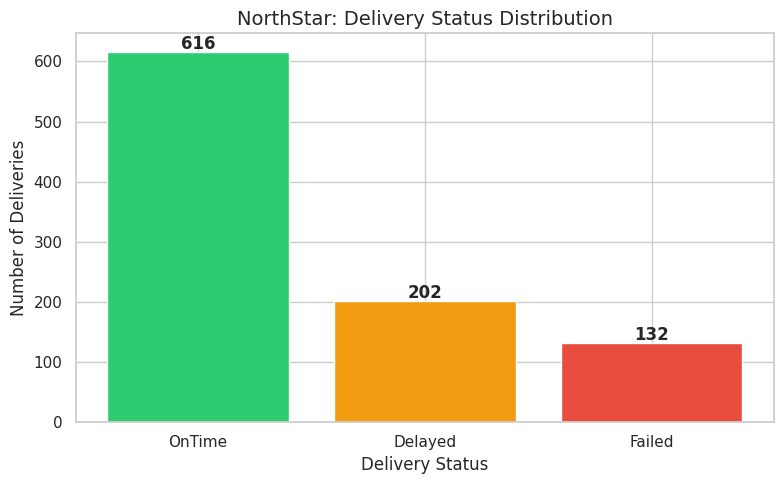

In [ ]:
# Visualisation 1: Delivery Status Distribution
delivery_counts = deliveries['delivery_status'].value_counts()

plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
plt.bar(delivery_counts.index, delivery_counts.values, color=colors)
plt.title('NorthStar: Delivery Status Distribution', fontsize=14)
plt.xlabel('Delivery Status')
plt.ylabel('Number of Deliveries')
for i, v in enumerate(delivery_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1145/1696846488.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=complaint_counts.values, y=complaint_counts.index, palette='Reds_r')


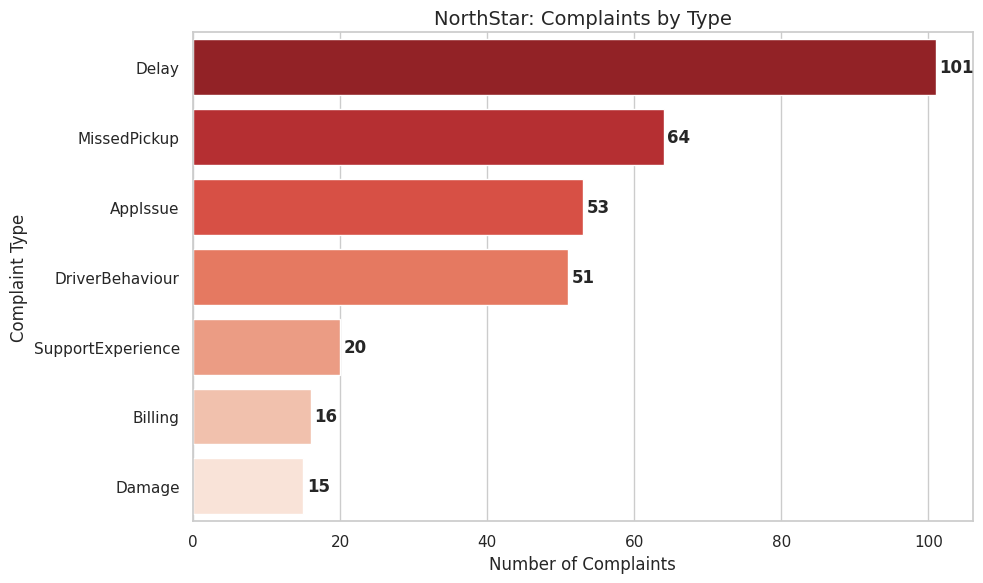

In [ ]:
# Visualisation 2: Complaints by Type
complaint_counts = complaints['complaint_type'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=complaint_counts.values, y=complaint_counts.index, palette='Reds_r')
plt.title('NorthStar: Complaints by Type', fontsize=14)
plt.xlabel('Number of Complaints')
plt.ylabel('Complaint Type')
for i, v in enumerate(complaint_counts.values):
    plt.text(v + 0.5, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1145/2177711415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='service_type', y='order_value', data=orders, palette='Set2')


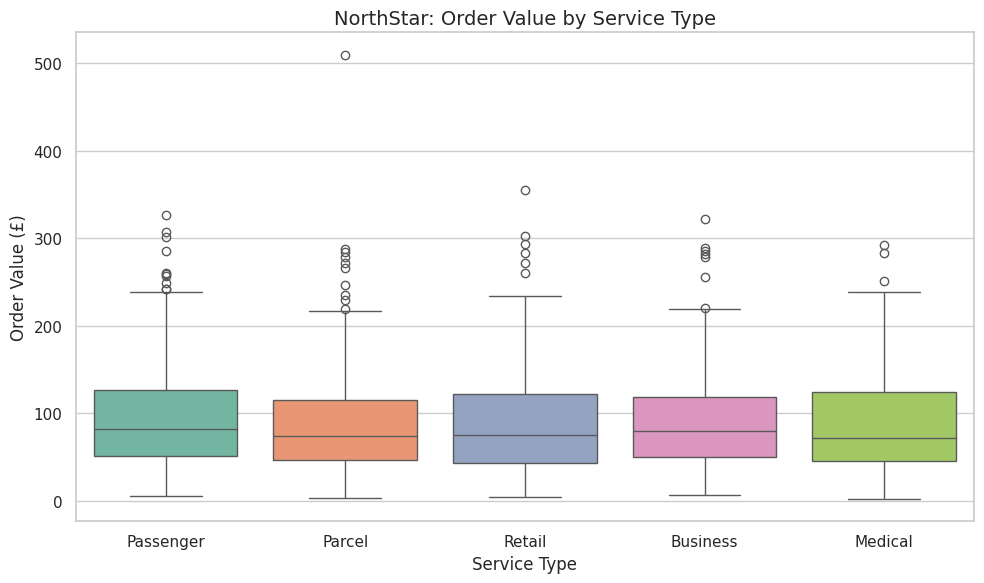

In [ ]:
# Visualisation 3: Order Value Distribution by Service Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='service_type', y='order_value', data=orders, palette='Set2')
plt.title('NorthStar: Order Value by Service Type', fontsize=14)
plt.xlabel('Service Type')
plt.ylabel('Order Value (£)')
plt.tight_layout()
plt.show()

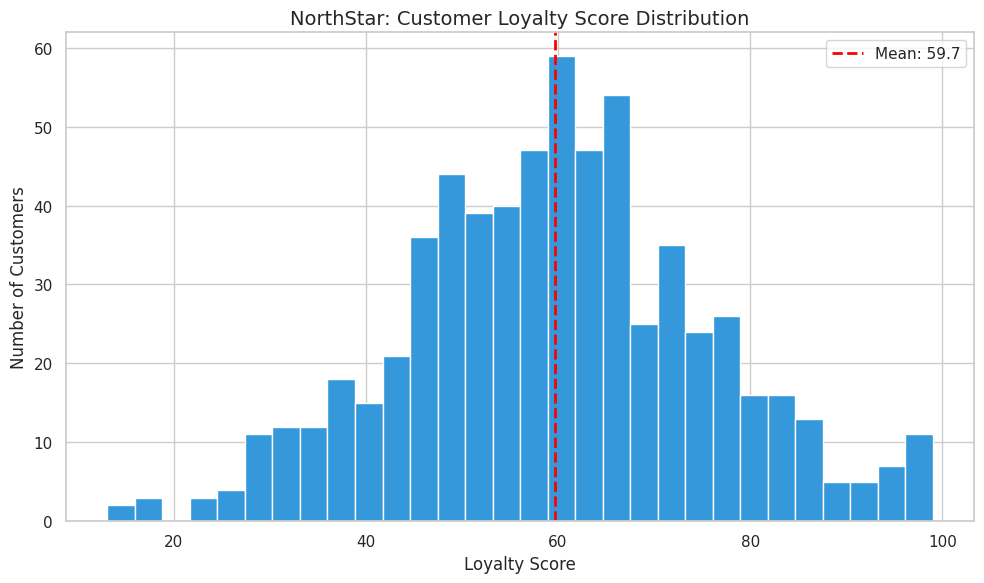

In [ ]:
# Visualisation 4: Customer Loyalty Score Distribution
plt.figure(figsize=(10, 6))
plt.hist(customers['loyalty_score'], bins=30, color='#3498db', edgecolor='white')
plt.title('NorthStar: Customer Loyalty Score Distribution', fontsize=14)
plt.xlabel('Loyalty Score')
plt.ylabel('Number of Customers')
plt.axvline(customers['loyalty_score'].mean(), color='red',
            linestyle='dashed', linewidth=2, label=f"Mean: {customers['loyalty_score'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

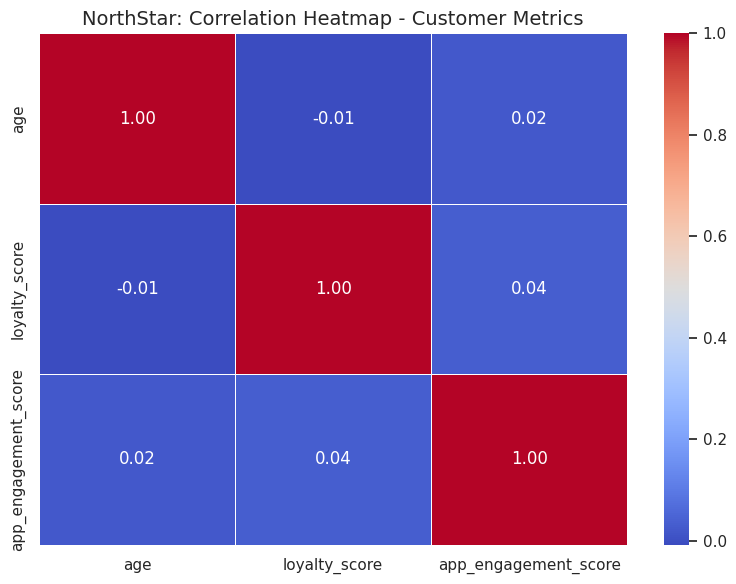

In [ ]:
# Visualisation 5: Correlation Heatmap
numeric_cols = customers[['age', 'loyalty_score', 'app_engagement_score']].copy()

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)
plt.title('NorthStar: Correlation Heatmap - Customer Metrics', fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1145/3700378870.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=incident_counts.index, y=incident_counts.values, palette='Blues_r')


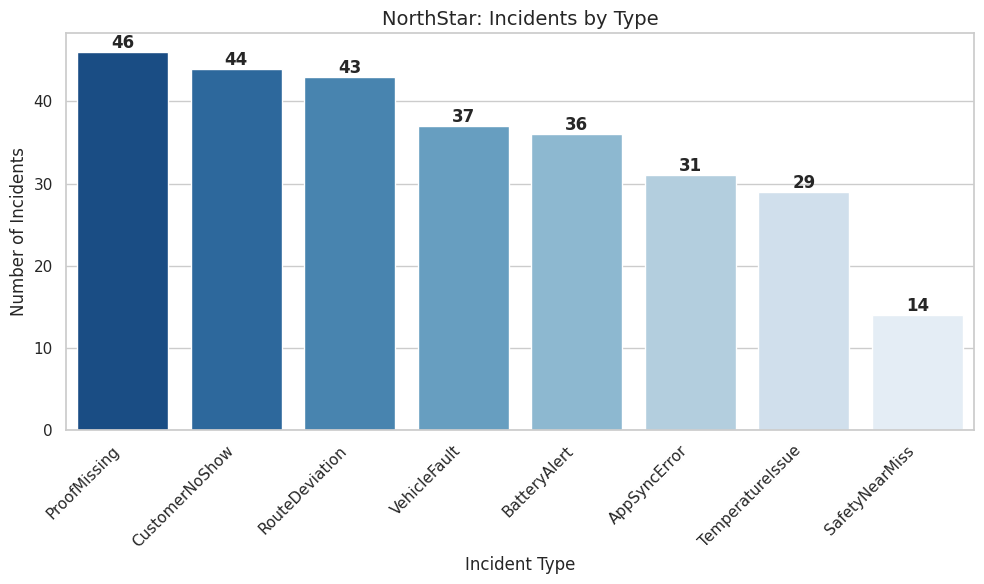

In [ ]:
# Visualisation 6: Incidents by Type
incident_counts = incidents['incident_type'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=incident_counts.index, y=incident_counts.values, palette='Blues_r')
plt.title('NorthStar: Incidents by Type', fontsize=14)
plt.xlabel('Incident Type')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(incident_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

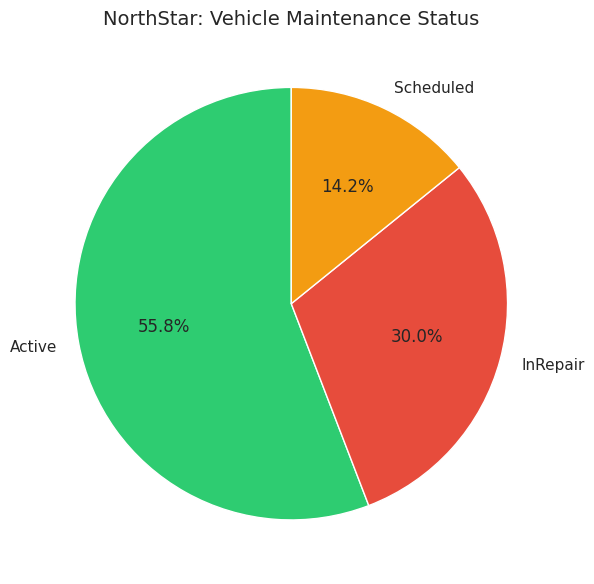

In [ ]:
# Visualisation 7: Vehicle Maintenance Status
maintenance_counts = vehicles['maintenance_status'].value_counts()

plt.figure(figsize=(8, 6))
colors = ['#2ecc71', '#e74c3c', '#f39c12']
plt.pie(maintenance_counts.values,
        labels=maintenance_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90)
plt.title('NorthStar: Vehicle Maintenance Status', fontsize=14)
plt.tight_layout()
plt.show()

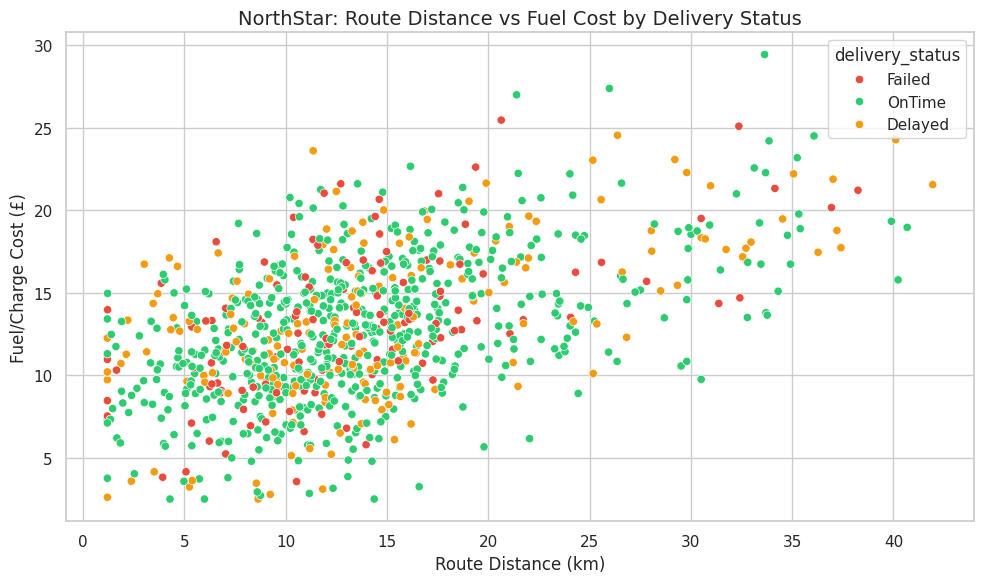

In [ ]:
# Visualisation 8: Scatter Plot - Route Distance vs Fuel Cost
plt.figure(figsize=(10, 6))
sns.scatterplot(x='route_distance_km',
                y='fuel_or_charge_cost',
                hue='delivery_status',
                data=deliveries,
                palette={'OnTime': '#2ecc71',
                         'Delayed': '#f39c12',
                         'Failed': '#e74c3c'})
plt.title('NorthStar: Route Distance vs Fuel Cost by Delivery Status', fontsize=14)
plt.xlabel('Route Distance (km)')
plt.ylabel('Fuel/Charge Cost (£)')
plt.tight_layout()
plt.show()

In [ ]:
# Summary Analysis: Key business insights
print("KEY BUSINESS INSIGHTS")

# 1. Delivery performance
total = len(deliveries)
failed = len(deliveries[deliveries['delivery_status'] == 'Failed'])
delayed = len(deliveries[deliveries['delivery_status'] == 'Delayed'])
print(f"\n1. Delivery Performance:")
print(f"   Failed deliveries: {failed} ({failed/total*100:.1f}%)")
print(f"   Delayed deliveries: {delayed} ({delayed/total*100:.1f}%)")
print(f"   Total underperforming: {failed+delayed} ({(failed+delayed)/total*100:.1f}%)")

# 2. Fleet availability
inactive = len(vehicles[vehicles['maintenance_status'] != 'Active'])
print(f"\n2. Fleet Availability:")
print(f"   Vehicles not active: {inactive} out of {len(vehicles)} ({inactive/len(vehicles)*100:.1f}%)")

# 3. Customer satisfaction
avg_rating = deliveries['customer_rating_post_delivery'].mean()
print(f"\n3. Customer Satisfaction:")
print(f"   Average rating: {avg_rating:.2f} out of 5")

# 4. Top complaint
top_complaint = complaints['complaint_type'].value_counts().index[0]
top_count = complaints['complaint_type'].value_counts().values[0]
print(f"\n4. Biggest Complaint: {top_complaint} ({top_count} cases)")

# 5. Most common incident
top_incident = incidents['incident_type'].value_counts().index[0]
print(f"\n5. Most Common Incident: {top_incident}")

KEY BUSINESS INSIGHTS

1. Delivery Performance:
   Failed deliveries: 132 (13.9%)
   Delayed deliveries: 202 (21.3%)
   Total underperforming: 334 (35.2%)

2. Fleet Availability:
   Vehicles not active: 53 out of 120 (44.2%)

3. Customer Satisfaction:
   Average rating: 3.87 out of 5

4. Biggest Complaint: Delay (101 cases)

5. Most Common Incident: ProofMissing
